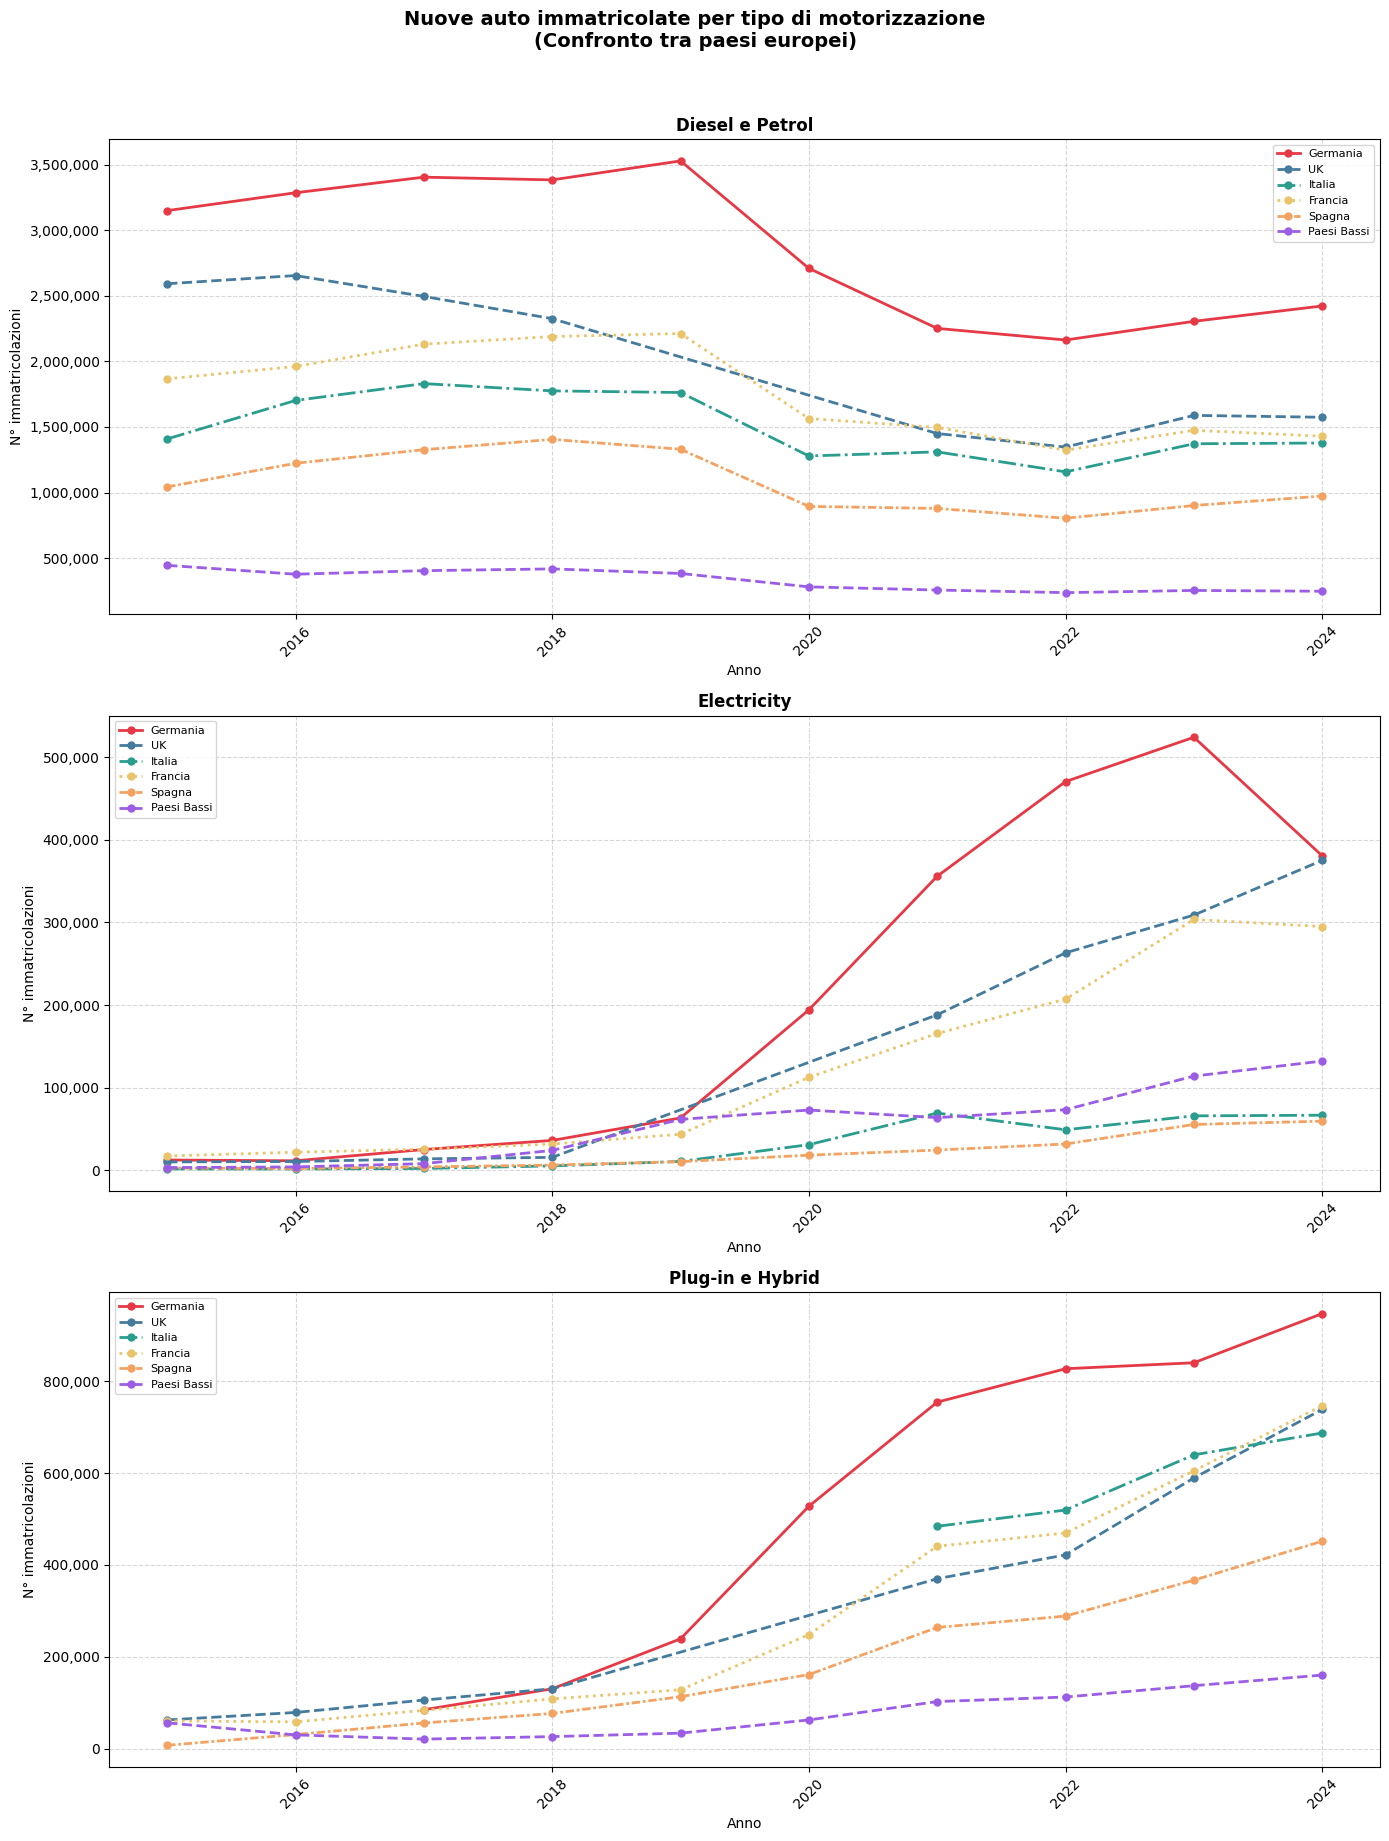

In [300]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Carica dati ──────────────────────────────────────────────────────────────
df = pd.read_csv('../data/csv/confronto_combustibili_europa.csv')

# ── Paesi di interesse ───────────────────────────────────────────────────────
countries = {
    'Germany':        'Germania',
    'United Kingdom': 'UK',
    'Italy':          'Italia',
    'France':         'Francia',
    'Spain':          'Spagna',
    'Netherlands':    'Paesi Bassi',
}

# ── Categorizzazione ─────────────────────────────────────────────────────────
def categorize(val):
    if pd.isna(val):
        return None
    v = str(val).lower().strip()
    if 'electric' in v and 'plug' not in v and 'hybrid' not in v:
        return 'Electricity'
    elif 'plug-in' in v or 'hybrid' in v:
        return 'Plug-in e Hybrid'
    elif 'diesel' in v or 'petrol' in v:
        return 'Diesel e Petrol'
    return None

df['Category'] = df['Motor energy'].apply(categorize)
df = df[df['Category'].notna()]

# ── Filtra paesi ─────────────────────────────────────────────────────────────
df = df[df['Geopolitical entity (reporting)'].isin(countries.keys())]
df['Country'] = df['Geopolitical entity (reporting)'].map(countries)

# ── Aggrega per anno, paese, categoria ───────────────────────────────────────
grouped = (df.groupby(['TIME_PERIOD', 'Country', 'Category'])['OBS_VALUE']
             .sum()
             .reset_index())

categories = ['Diesel e Petrol', 'Electricity', 'Plug-in e Hybrid']
colors = {
    'Germania':   '#E63946',
    'UK':         '#457B9D',
    'Italia':     '#2A9D8F',
    'Francia':    '#E9C46A',
    'Spagna':     '#F4A261',
    'Paesi Bassi':'#9B5DE5',
}
linestyles = {
    'Germania':   '-',
    'UK':         '--',
    'Italia':     '-.',
    'Francia':    ':',
    'Spagna':     (0, (3, 1, 1, 1)),
    'Paesi Bassi':'--',
}

# ── Grafico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharey=False)
fig.suptitle('Nuove auto immatricolate per tipo di motorizzazione\n(Confronto tra paesi europei)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, cat in zip(axes, categories):
    data_cat = grouped[grouped['Category'] == cat]
    for country in countries.values():
        data_c = data_cat[data_cat['Country'] == country].sort_values('TIME_PERIOD')
        if data_c.empty:
            continue
        ax.plot(data_c['TIME_PERIOD'], data_c['OBS_VALUE'],
                label=country,
                color=colors[country],
                linestyle=linestyles[country],
                linewidth=2,
                marker='o', markersize=5)

    ax.set_title(cat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Anno')
    ax.set_ylabel('N° immatricolazioni')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

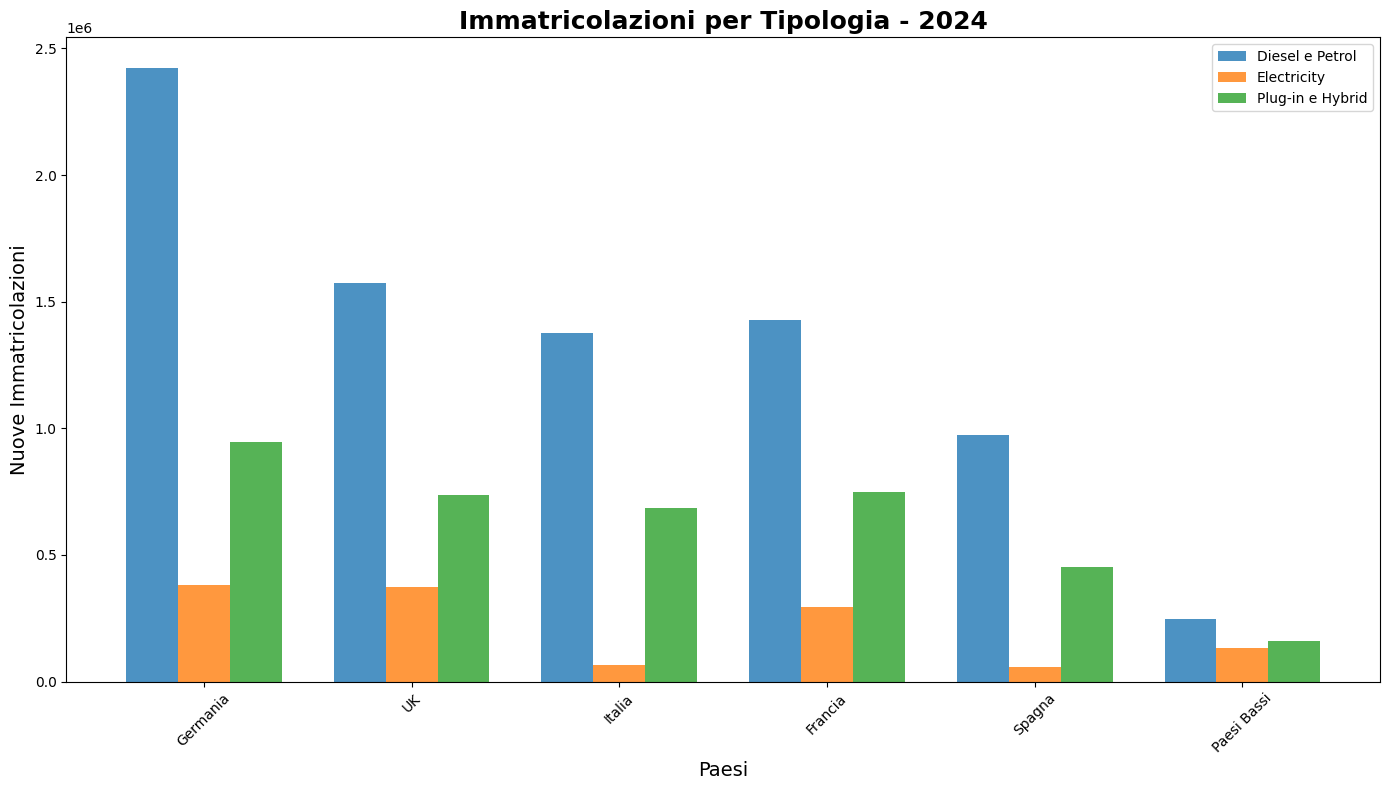

In [301]:
# Dati ultimo anno disponibile
last_year = grouped['TIME_PERIOD'].max()
last_data = grouped[grouped['TIME_PERIOD'] == last_year]

fig, ax = plt.subplots(figsize=(14, 8))
width = 0.25
x = range(len(countries.values()))

for i, cat in enumerate(categories):
    data_cat = last_data[last_data['Category'] == cat]
    values = [data_cat[data_cat['Country'] == country]['OBS_VALUE'].iloc[0] if not data_cat[data_cat['Country'] == country].empty else 0 
              for country in countries.values()]
    ax.bar([p + i*width for p in x], values, width, label=cat, alpha=0.8)

ax.set_title(f'Immatricolazioni per Tipologia - {last_year}', fontsize=18, fontweight='bold')
ax.set_xlabel('Paesi', fontsize=14)
ax.set_ylabel('Nuove Immatricolazioni', fontsize=14)
ax.set_xticks([p + width for p in x])
ax.set_xticklabels(countries.values())
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_115758/1580498359.py:33: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_115758/1580498359.py:33: UserWarning: Glyph 127481 (\N{REGIONAL INDICATOR SYMBOL LETTER T}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/matteo/.local/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127470 (\N{REGIONAL INDICATOR SYMBOL LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/matteo/.local/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127481 (\N{REGIONAL INDICATOR SYMBOL LETTER T}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


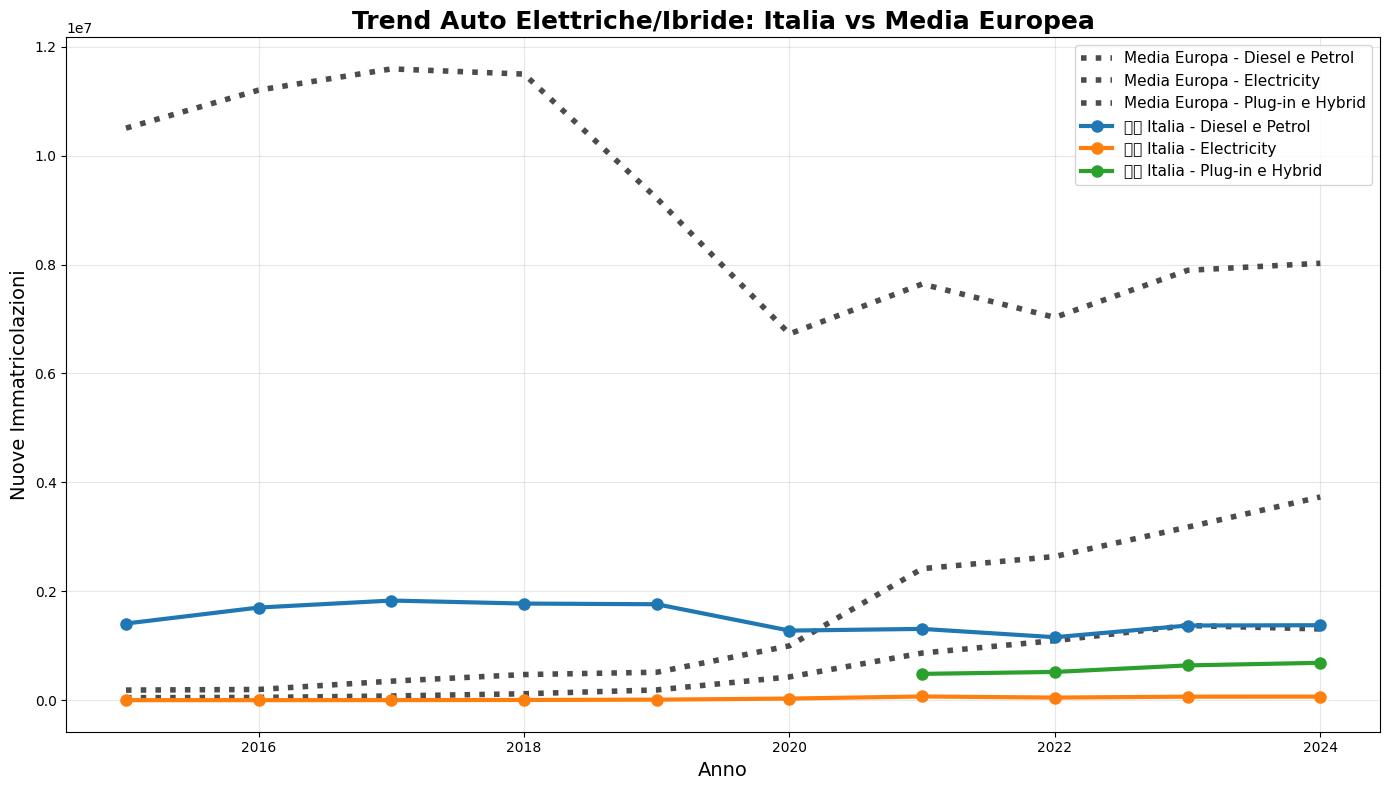

In [302]:
# Variante 5: Grafico a Linee con Media Europea + Italia in Evidenza
# CODICE CORRETTO

# Calcola media europea
europe_avg = grouped.groupby(['TIME_PERIOD', 'Category'])['OBS_VALUE'].sum().reset_index()
europe_avg['Country'] = 'Media Europa'

fig, ax = plt.subplots(figsize=(14, 8))

# Media Europa
for cat in categories:
    data = europe_avg[europe_avg['Category'] == cat]
    if not data.empty:
        ax.plot(data['TIME_PERIOD'], data['OBS_VALUE'], 
                linewidth=4, linestyle=':', color='black', alpha=0.7, 
                label=f'Media Europa - {cat}')

# Italia in evidenza
italia_data = grouped[grouped['Country'] == 'Italia']
for cat in categories:
    data = italia_data[italia_data['Category'] == cat]
    if not data.empty:
        ax.plot(data['TIME_PERIOD'], data['OBS_VALUE'], 
                marker='o', markersize=8, linewidth=3,  # linewidth UNA SOLA VOLTA
                label=f'🇮🇹 Italia - {cat}')

ax.set_title('Trend Auto Elettriche/Ibride: Italia vs Media Europea', fontsize=18, fontweight='bold')
ax.set_xlabel('Anno', fontsize=14)
ax.set_ylabel('Nuove Immatricolazioni', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


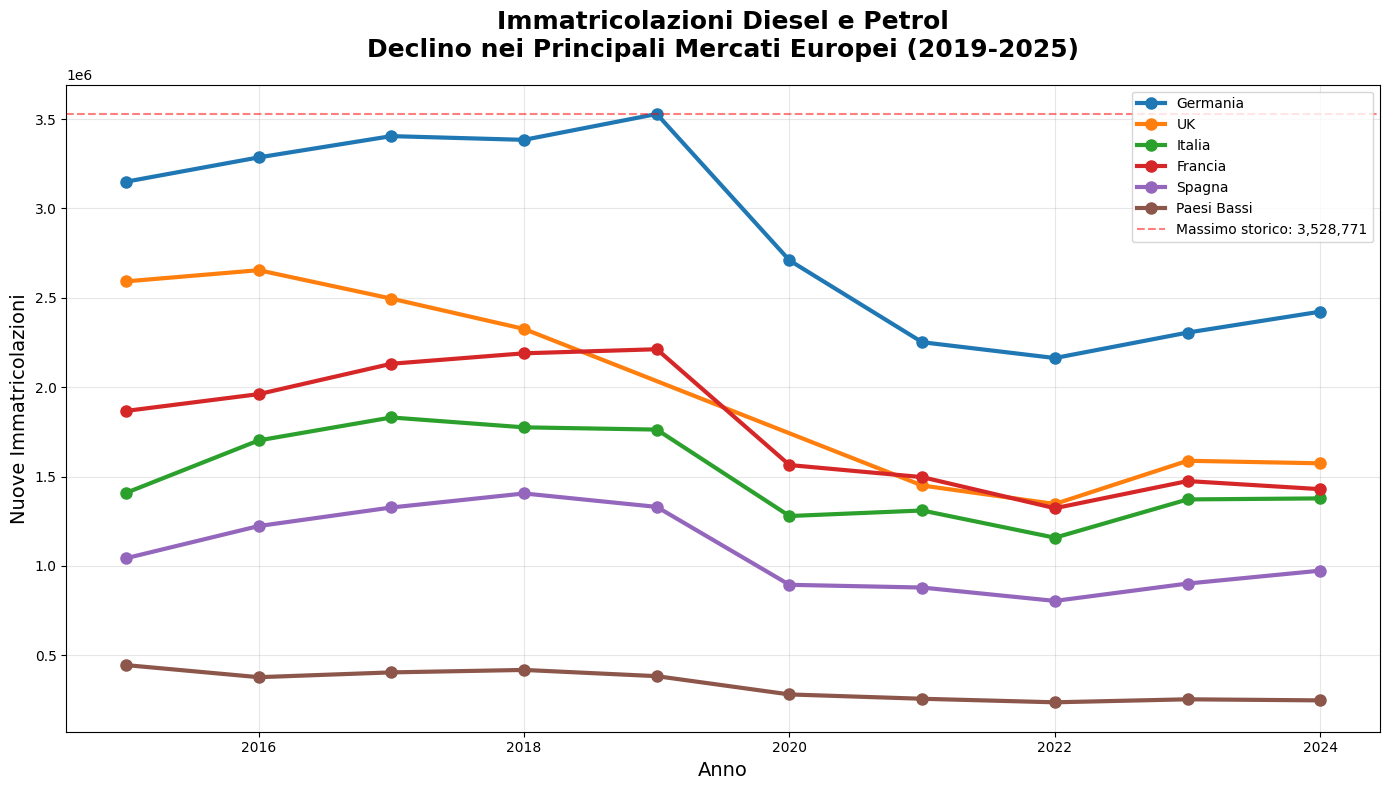

In [303]:
# VARIANTE 6: Focus DIESEL E PETROL
diesel_data = grouped[grouped['Category'] == 'Diesel e Petrol']

fig, ax = plt.subplots(figsize=(14, 8))

for country in countries.values():
    data_country = diesel_data[diesel_data['Country'] == country].sort_values('TIME_PERIOD')
    if not data_country.empty:
        ax.plot(data_country['TIME_PERIOD'], data_country['OBS_VALUE'], 
                linewidth=3, marker='o', markersize=8,
                label=country)

ax.set_title('Immatricolazioni Diesel e Petrol\nDeclino nei Principali Mercati Europei (2019-2025)', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Anno', fontsize=14)
ax.set_ylabel('Nuove Immatricolazioni', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=0)

# Evidenzia trend negativo
ax.axhline(y=diesel_data['OBS_VALUE'].max(), color='red', linestyle='--', alpha=0.5, 
           label=f'Massimo storico: {int(diesel_data["OBS_VALUE"].max()):,}')
ax.legend()

plt.tight_layout()
plt.show()


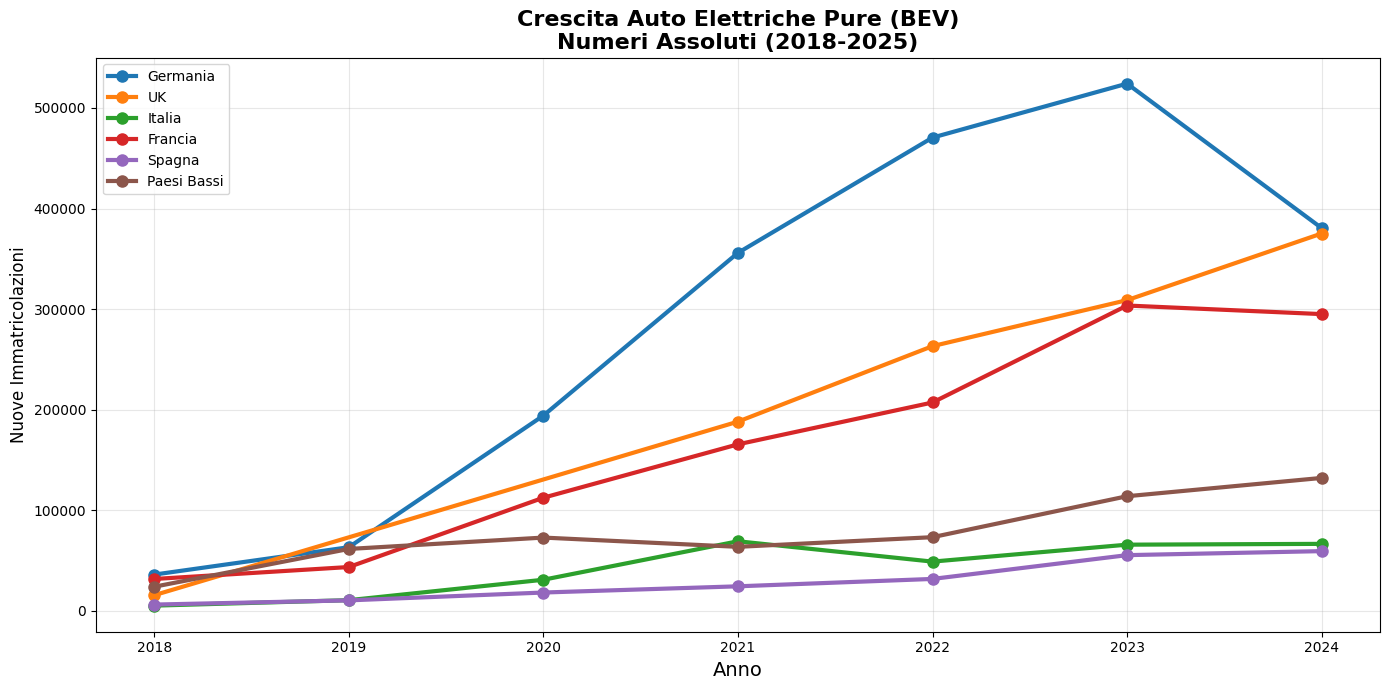

In [304]:
# GRAFICO 1: Numeri assoluti - dal 2018
elec_data = grouped[grouped['Category'] == 'Electricity']
elec_data_filtered = elec_data[elec_data['TIME_PERIOD'] >= 2018]

fig, ax1 = plt.subplots(figsize=(14, 7))

for country in countries.values():
    data_country = elec_data_filtered[elec_data_filtered['Country'] == country].sort_values('TIME_PERIOD')
    if not data_country.empty:
        ax1.plot(data_country['TIME_PERIOD'], data_country['OBS_VALUE'], 
                 linewidth=3, marker='o', markersize=8, label=country)

ax1.set_title('Crescita Auto Elettriche Pure (BEV)\nNumeri Assoluti (2018-2025)', 
              fontsize=16, fontweight='bold')
ax1.set_xlabel('Anno', fontsize=14)
ax1.set_ylabel('Nuove Immatricolazioni', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

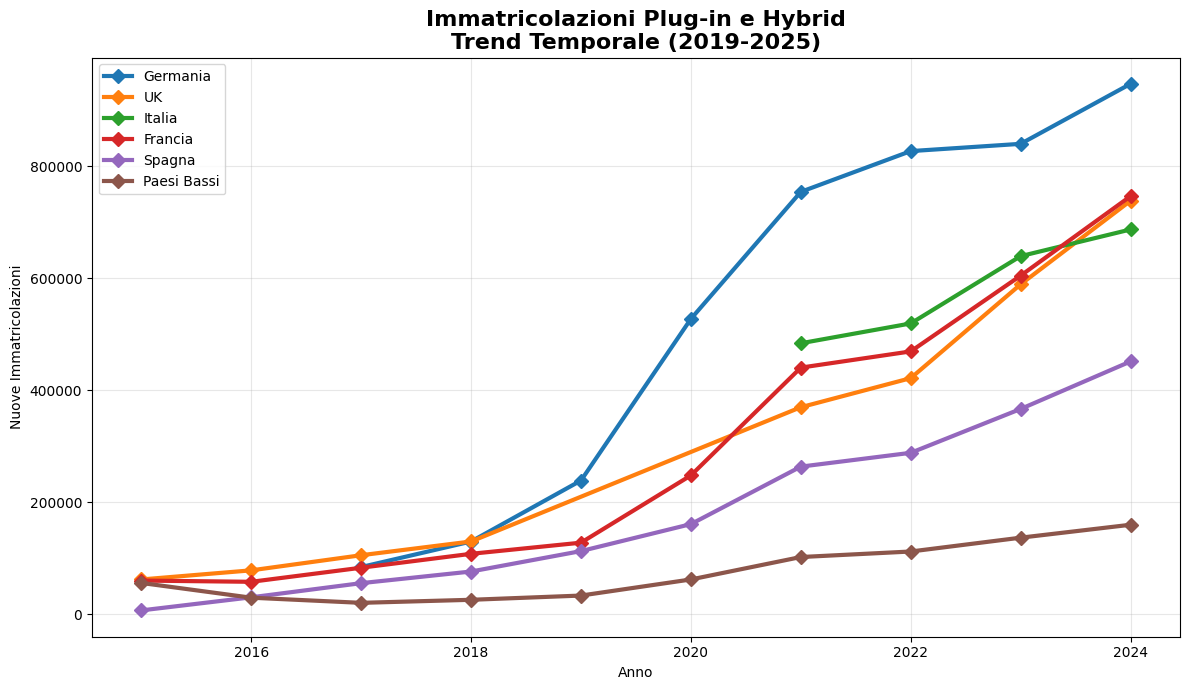

In [305]:
# GRAFICO 1: Trend linee
hybrid_data = grouped[grouped['Category'] == 'Plug-in e Hybrid']

fig1, ax1 = plt.subplots(figsize=(12, 7))

for country in countries.values():
    data_country = hybrid_data[hybrid_data['Country'] == country].sort_values('TIME_PERIOD')
    if not data_country.empty:
        ax1.plot(data_country['TIME_PERIOD'], data_country['OBS_VALUE'], 
                 linewidth=3, marker='D', markersize=7, label=country)

ax1.set_title('Immatricolazioni Plug-in e Hybrid\nTrend Temporale (2019-2025)', 
              fontsize=16, fontweight='bold')
ax1.set_xlabel('Anno')
ax1.set_ylabel('Nuove Immatricolazioni')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('hybrid_trend.png', dpi=150, bbox_inches='tight')
plt.show()

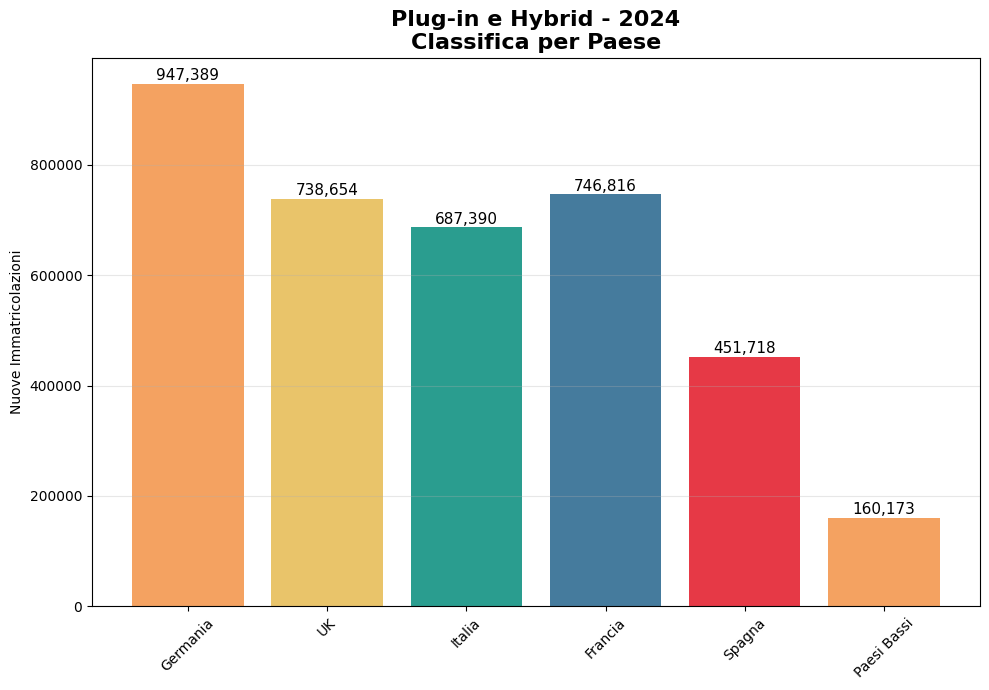

In [306]:
# GRAFICO 2: Barre ultimo anno
last_year = hybrid_data['TIME_PERIOD'].max()
last_hybrid = hybrid_data[hybrid_data['TIME_PERIOD'] == last_year]

countries_order = [c for c in countries.values() if not last_hybrid[last_hybrid['Country'] == c].empty]
values = [last_hybrid[last_hybrid['Country'] == c]['OBS_VALUE'].iloc[0] 
          for c in countries_order]

fig2, ax2 = plt.subplots(figsize=(10, 7))

bars = ax2.bar(countries_order, values, color=['#F4A261', '#E9C46A', '#2A9D8F', '#457B9D', '#E63946'])
ax2.set_title(f'Plug-in e Hybrid - {last_year}\nClassifica per Paese', fontsize=16, fontweight='bold')
ax2.set_ylabel('Nuove Immatricolazioni')

for bar, val in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{int(val):,}', ha='center', va='bottom', fontsize=11)

ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('hybrid_barre.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_115758/1068431654.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_by_country, labels=labels)
/tmp/ipykernel_115758/1068431654.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_by_country, labels=labels)
/tmp/ipykernel_115758/1068431654.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data_by_country, labels=labels)


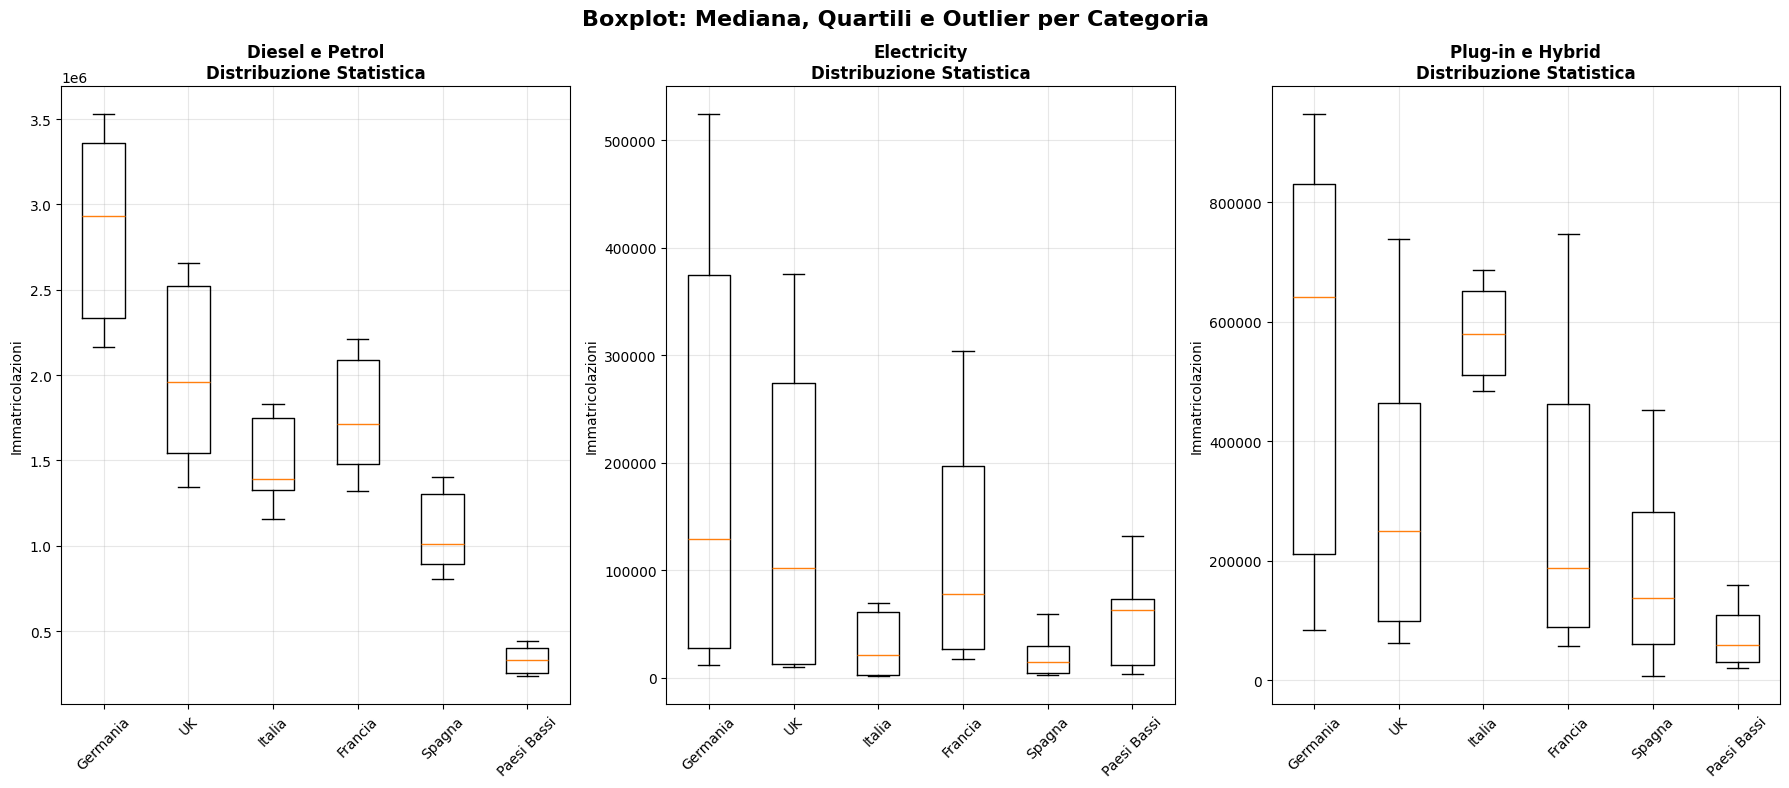

In [307]:
# VARIANTE 10: BOXPLOT - Statistiche per Categoria e Paese
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for idx, cat in enumerate(categories):
    cat_data = grouped[grouped['Category'] == cat]
    
    # Prepara dati per boxplot
    data_by_country = []
    labels = []
    for country in countries.values():
        country_data = cat_data[cat_data['Country'] == country]['OBS_VALUE']
        if not country_data.empty:
            data_by_country.append(country_data)
            labels.append(country)
    
    axes[idx].boxplot(data_by_country, labels=labels)
    axes[idx].set_title(f'{cat}\nDistribuzione Statistica', fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylabel('Immatricolazioni')

plt.suptitle('Boxplot: Mediana, Quartili e Outlier per Categoria', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


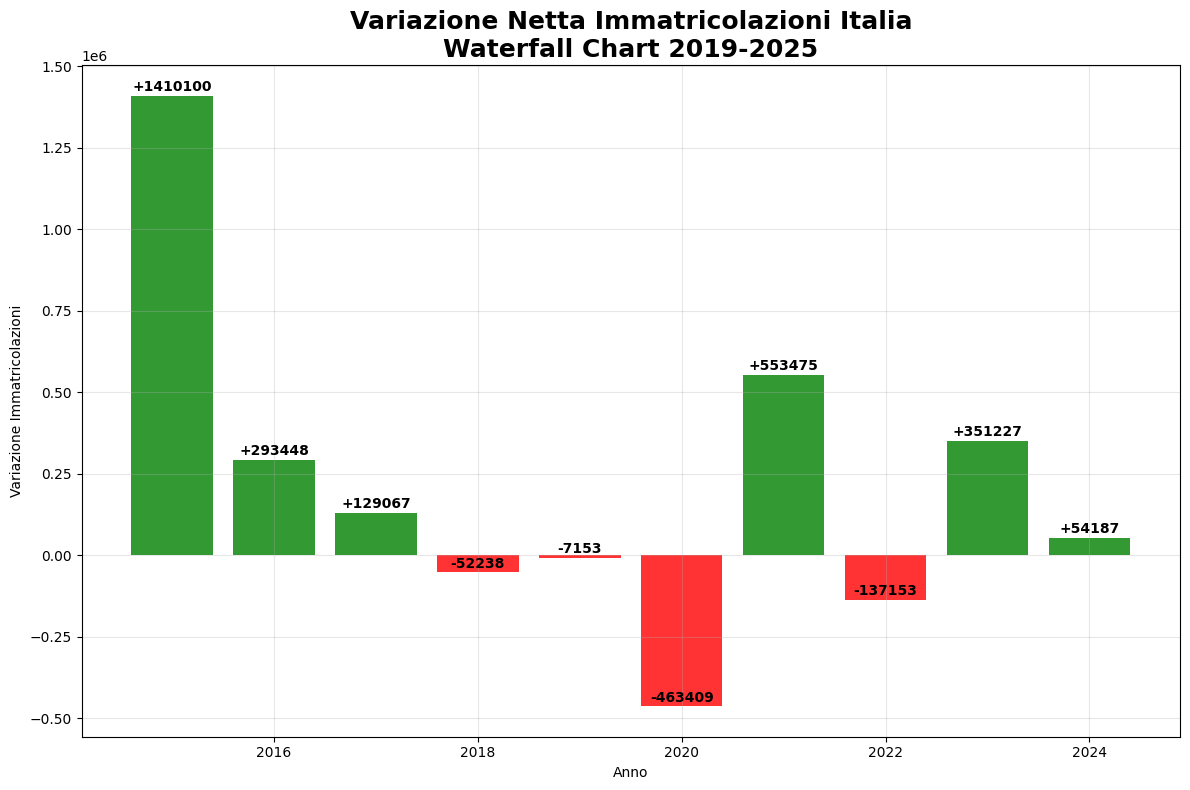

In [308]:
# VARIANTE 13: WATERFALL - Variazione Netta Italia 2019→2025
italia_total = grouped[grouped['Country'] == 'Italia'].groupby('TIME_PERIOD')['OBS_VALUE'].sum().reset_index()

# Calcola variazioni
italia_total['Delta'] = italia_total['OBS_VALUE'].diff()
italia_total.loc[0, 'Delta'] = italia_total.loc[0, 'OBS_VALUE']

fig, ax = plt.subplots(figsize=(12, 8))

# Waterfall bars
colors = ['green' if x > 0 else 'red' for x in italia_total['Delta']]
bars = ax.bar(italia_total['TIME_PERIOD'], italia_total['Delta'], color=colors, alpha=0.8)

# Annotazioni
for bar, delta in zip(bars, italia_total['Delta']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5000,
            f'{int(delta):+d}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Variazione Netta Immatricolazioni Italia\nWaterfall Chart 2019-2025', fontsize=18, fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('Variazione Immatricolazioni')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


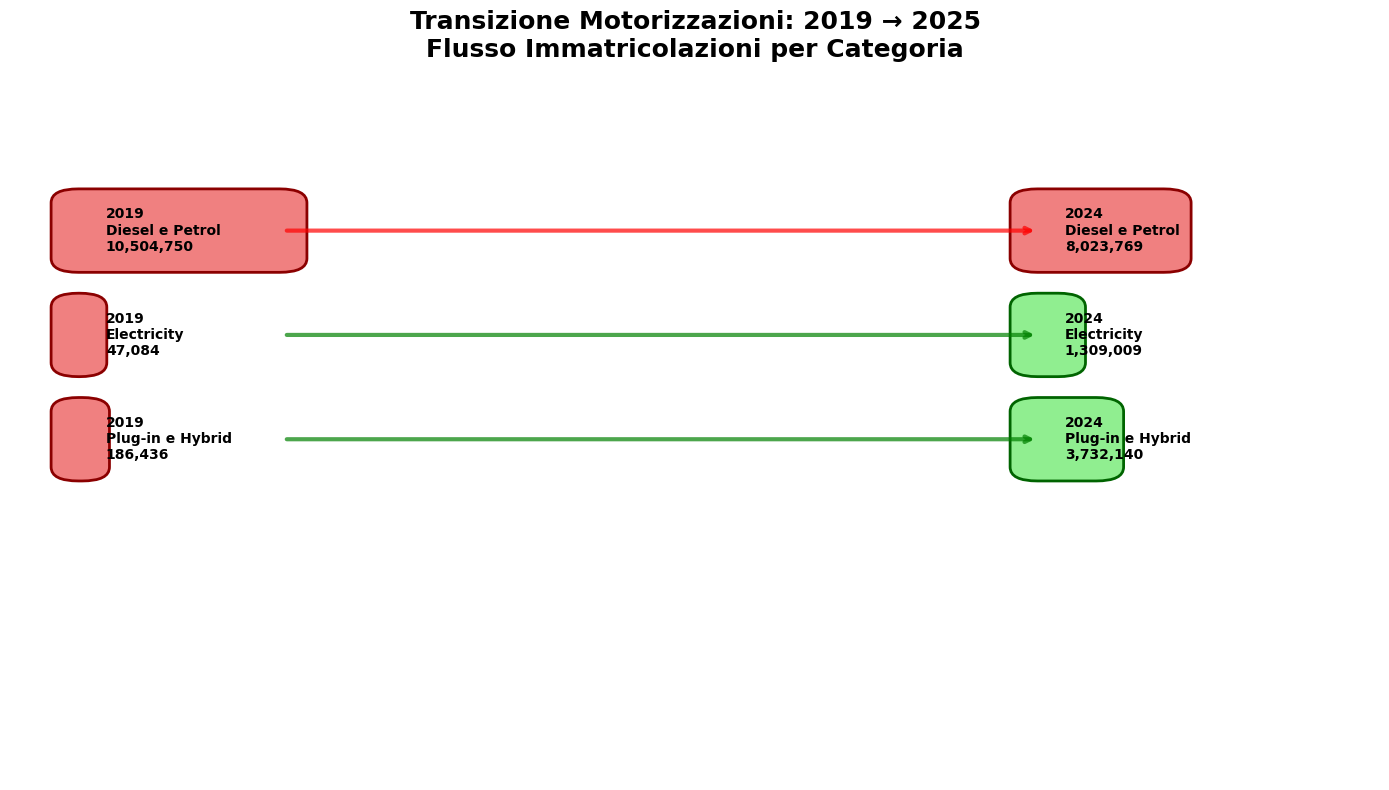

✓ Sankey Diagram con solo matplotlib!


In [309]:
# VARIANTE 11: SANKEY con MATPLOTLIB - NO PLOTLY RICHIESTO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch

# Dati primo vs ultimo anno
first_year = grouped['TIME_PERIOD'].min()
last_year = grouped['TIME_PERIOD'].max()

first_data = grouped[grouped['TIME_PERIOD'] == first_year].groupby('Category')['OBS_VALUE'].sum()
last_data = grouped[grouped['TIME_PERIOD'] == last_year].groupby('Category')['OBS_VALUE'].sum()

fig, ax = plt.subplots(figsize=(14, 8))

# Posizioni nodi
node_positions = {
    '2019_Diesel': (0.1, 0.8), '2019_Electricity': (0.1, 0.5), '2019_Hybrid': (0.1, 0.2),
    f'{last_year}_Diesel': (0.8, 0.8), f'{last_year}_Electricity': (0.8, 0.5), f'{last_year}_Hybrid': (0.8, 0.2)
}

categories = ['Diesel e Petrol', 'Electricity', 'Plug-in e Hybrid']

# Disegna nodi (rettangoli)
for i, cat in enumerate(categories):
    # Nodo 2019
    width1 = first_data[cat] / first_data.sum() * 0.15
    rect1 = FancyBboxPatch((0.05, 0.75 - i*0.15), width1, 0.08, 
                          boxstyle="round,pad=0.02", facecolor='lightcoral', 
                          edgecolor='darkred', linewidth=2)
    ax.add_patch(rect1)
    ax.text(0.07, 0.79 - i*0.15, f'2019\n{cat}\n{int(first_data[cat]):,}', 
            va='center', fontweight='bold')
    
    # Nodo 2025
    width2 = last_data[cat] / last_data.sum() * 0.15
    rect2 = FancyBboxPatch((0.75, 0.75 - i*0.15), width2, 0.08, 
                          boxstyle="round,pad=0.02", facecolor='lightgreen' if cat != 'Diesel e Petrol' else 'lightcoral',
                          edgecolor='darkgreen' if cat != 'Diesel e Petrol' else 'darkred', linewidth=2)
    ax.add_patch(rect2)
    ax.text(0.77, 0.79 - i*0.15, f'{last_year}\n{cat}\n{int(last_data[cat]):,}', 
            va='center', fontweight='bold')

# Disegna flussi (frecce)
for i, cat in enumerate(categories):
    y_start = 0.79 - i*0.15
    ax.annotate('', xy=(0.75, y_start), xytext=(0.2, y_start),
                arrowprops=dict(arrowstyle='->', lw=3, 
                              color='red' if cat == 'Diesel e Petrol' else 'green',
                              alpha=0.7))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.title('Transizione Motorizzazioni: 2019 → 2025\nFlusso Immatricolazioni per Categoria', 
          fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ Sankey Diagram con solo matplotlib!")


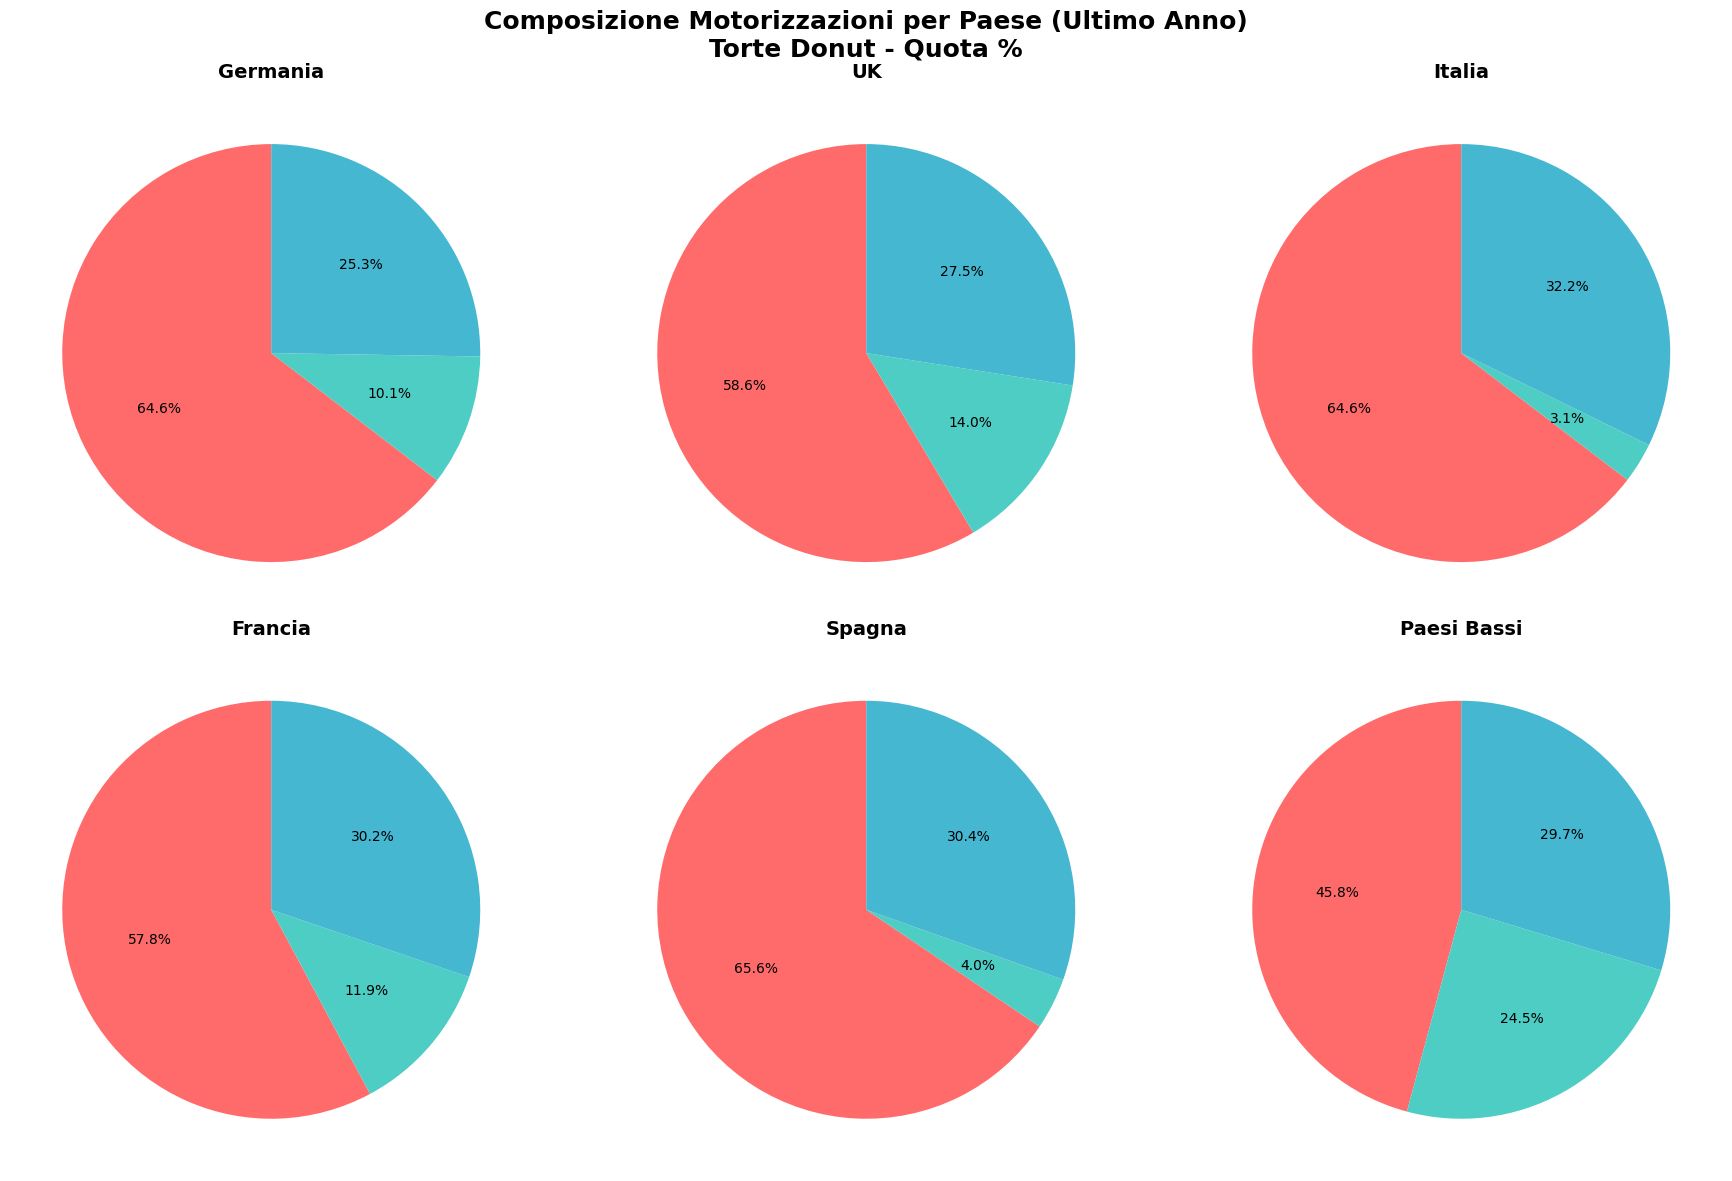

In [310]:
# VARIANTE 12B: DONUT CHARTS - Quota % per Paese (2025)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

last_year_data = grouped[grouped['TIME_PERIOD'] == grouped['TIME_PERIOD'].max()]

for idx, country in enumerate(countries.values()):
    country_data = last_year_data[last_year_data['Country'] == country]
    if not country_data.empty:
        country_total = country_data['OBS_VALUE'].sum()
        sizes = [country_data[country_data['Category'] == cat]['OBS_VALUE'].sum() / country_total * 100 
                 for cat in categories]
        labels = [f'{cat[:15]}\n{size:.0f}%' for cat, size in zip(categories, sizes)]
        
        wedges, texts, autotexts = axes[idx].pie(sizes, autopct='%1.1f%%', 
                                                startangle=90, colors=['#FF6B6B', '#4ECDC4', '#45B7D1'],
                                                textprops={'fontsize': 10})
        
        axes[idx].set_title(f'{country}', fontsize=14, fontweight='bold', pad=10)
    else:
        axes[idx].text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=14)
        axes[idx].set_title(country)

plt.suptitle('Composizione Motorizzazioni per Paese (Ultimo Anno)\nTorte Donut - Quota %', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


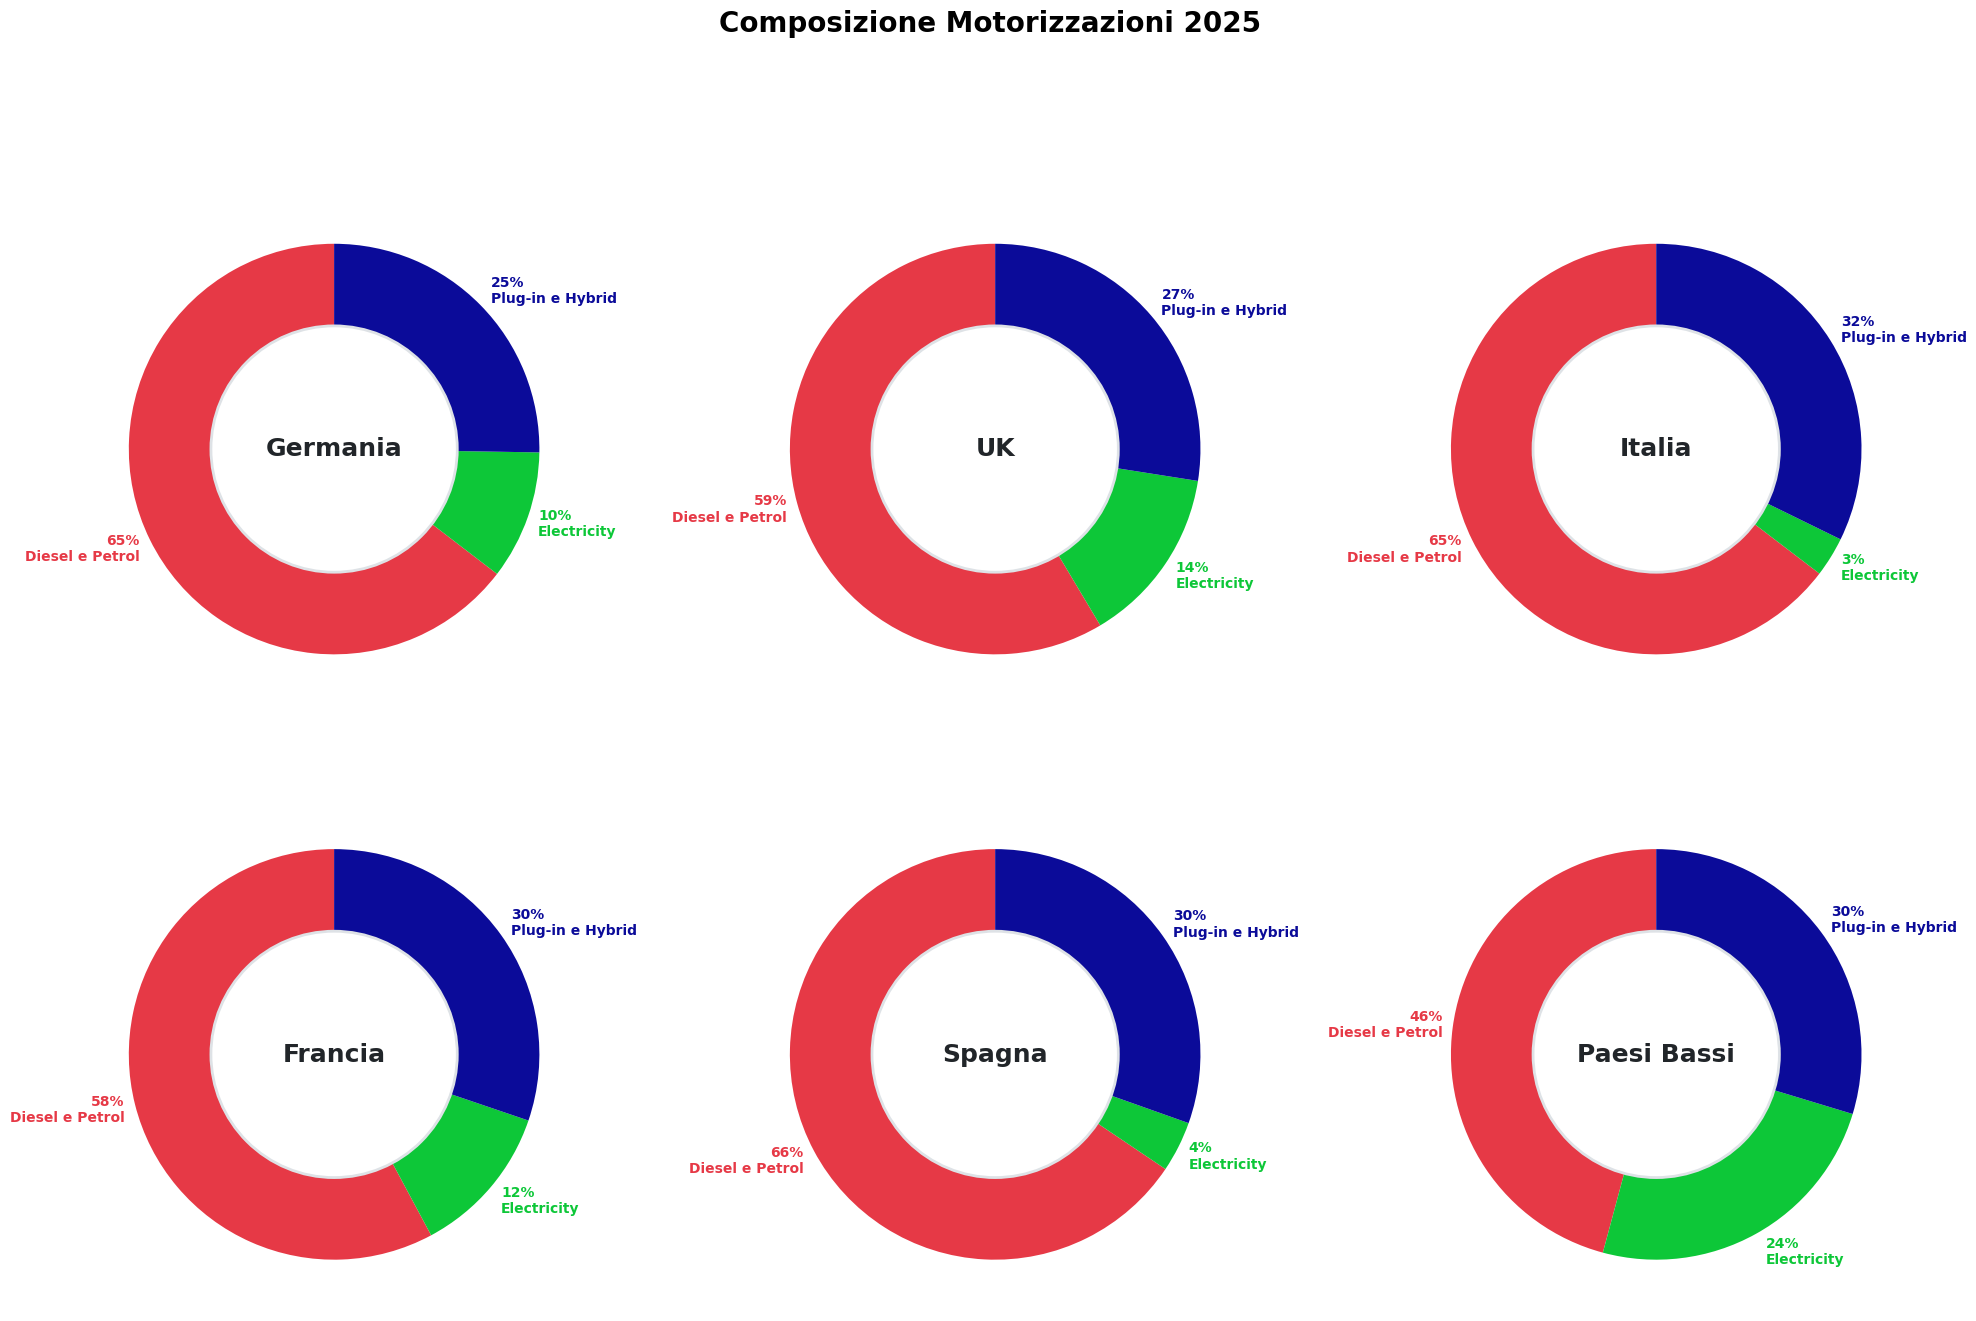

In [311]:
# VARIANTE 12B: DONUT con % ESTERNE + TOTALI
import matplotlib.pyplot as plt
import numpy as np

# Colori unici per nazione
country_colors = {
    'Germania': ['#E63946', '#0DC738', '#0B0B99'],
    'UK': ['#E63946', '#0DC738', "#0B0B99"],
    'Italia': ['#E63946', '#0DC738', '#0B0B99'],
    'Francia': ['#E63946', "#0DC738", '#0B0B99'],
    'Spagna': ['#E63946', '#0DC738', '#0B0B99'],
    'Paesi Bassi': ['#E63946', '#0DC738', '#0B0B99']
}

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.ravel()

# SFONDO BIANCO
fig.patch.set_facecolor('white')

fig.suptitle('Composizione Motorizzazioni 2025\n\n\n', 
             fontsize=20, fontweight='bold', y=0.98)

last_year_data = grouped[grouped['TIME_PERIOD'] == grouped['TIME_PERIOD'].max()]

for idx, country in enumerate(countries.values()):
    country_data = last_year_data[last_year_data['Country'] == country]
    
    # Sfondo bianco anche per ogni subplot
    axes[idx].set_facecolor('white')
    
    if not country_data.empty:
        country_total = country_data['OBS_VALUE'].sum()
        sizes = [country_data[country_data['Category'] == cat]['OBS_VALUE'].sum() / country_total * 100 
                 for cat in categories]
        etichette_fette = categories

        colori_paese = country_colors.get(country, ['#FF6B6B', '#4ECDC4', '#45B7D1'])

        # Pie donut
        wedges = axes[idx].pie(sizes, radius=1, labels=None, autopct=None,
                               startangle=90, colors=colori_paese, shadow=False)[0]

        # BUCO CENTRALE
        centre_circle = plt.Circle((0, 0), 0.60, fc='white', linewidth=2, edgecolor='#DEE2E6')
        axes[idx].add_patch(centre_circle)

        # NOME STATO IN CENTRO — grande e in rilievo
        axes[idx].text(0, 0, country, ha='center', va='center',
                       fontsize=18, fontweight='bold', color='#212529',
                       bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none'))

    
        # % ESTERNE con linee di collegamento
        for i, (wedge, size, etichetta) in enumerate(zip(wedges, sizes, etichette_fette)):
            ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
            ang_rad = np.radians(ang)


            # Punto etichetta esterna
            x_outer = 1 * np.cos(ang_rad)
            y_outer = 1.1 * np.sin(ang_rad)

        
            # Testo % + etichetta abbreviata
            ha = 'left' if np.cos(ang_rad) >= 0 else 'right'
            axes[idx].text(x_outer + (0.05 if np.cos(ang_rad) >= 0 else -0.05),
                           y_outer,
                           f'{size:.0f}%\n{etichetta}',
                           fontsize=10, fontweight='bold',
                           ha=ha, va='center',
                           color=colori_paese[i])

        # Rimuove titolo sopra (già nel centro)
        axes[idx].set_title('', pad=10)

    else:
        axes[idx].text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=16)

plt.tight_layout()
plt.show()

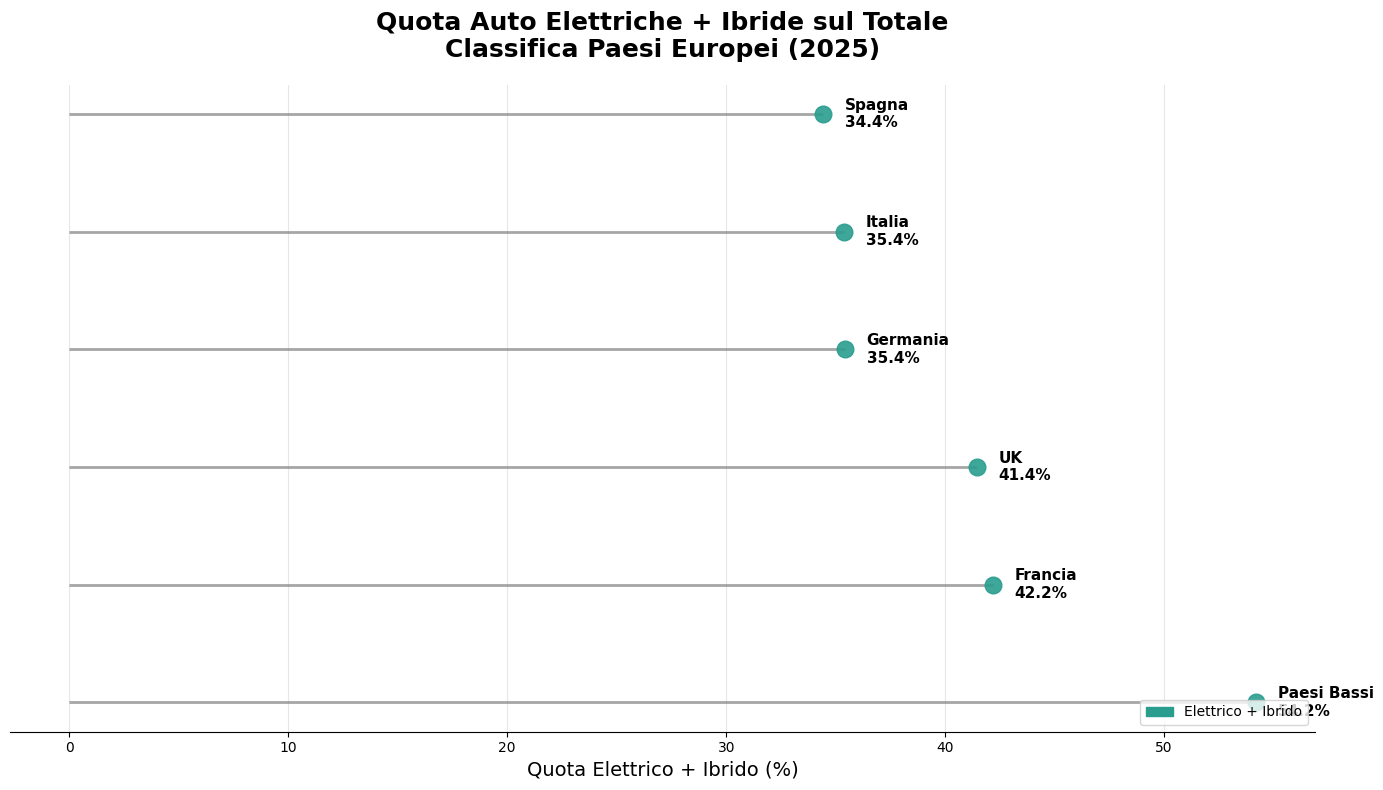

In [312]:
# VARIANTE 12C: LOLLIPOP CHART - Quota Elettrico 2025
import matplotlib.patches as mpatches

last_year_data = grouped[grouped['TIME_PERIOD'] == grouped['TIME_PERIOD'].max()]

# Solo quota elettrico + ibrido
elec_plus_hybrid = {}
for country in countries.values():
    country_data = last_year_data[last_year_data['Country'] == country]
    if not country_data.empty:
        total = country_data['OBS_VALUE'].sum()
        elec_hybrid = country_data[country_data['Category'].isin(['Electricity', 'Plug-in e Hybrid'])]['OBS_VALUE'].sum()
        elec_plus_hybrid[country] = (elec_hybrid / total) * 100

# Ordina per quota decrescente
sorted_countries = dict(sorted(elec_plus_hybrid.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(14, 8))

y_pos = np.arange(len(sorted_countries))
percentages = list(sorted_countries.values())

# Linee + punti
ax.hlines(y_pos, 0, percentages, color='gray', alpha=0.7, linewidth=2)
ax.plot(percentages, y_pos, "o", markersize=12, color='#2A9D8F', alpha=0.9)

# Etichette
for i, (country, pct) in enumerate(sorted_countries.items()):
    ax.text(pct + 1, i, f'{country}\n{pct:.1f}%', va='center', fontweight='bold', fontsize=11)

ax.set_yticks([])
ax.set_xlabel('Quota Elettrico + Ibrido (%)', fontsize=14)
ax.set_title('Quota Auto Elettriche + Ibride sul Totale\nClassifica Paesi Europei (2025)', 
             fontsize=18, fontweight='bold', pad=20)
ax.grid(True, axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Legenda
legend_elements = [mpatches.Circle((0,0), 0.1, color='#2A9D8F', label='Elettrico + Ibrido')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()
